In [ ]:
import numpy as np
import spikeinterface as si
import matplotlib.pyplot as plt

from spikeinterface.core import BaseRecording, BaseRecordingSegment
from spikeinterface import NumpyRecording, NumpySorting
from spikeinterface import append_recordings, concatenate_recordings
from spikeinterface.core import write_binary_recording

class DecimatedRecordingSegment(BaseRecordingSegment):
    """Recording segment that decimates on-the-fly by selecting every k-th sample."""
    
    def __init__(self, parent_segment, decimation_factor):
        self._parent_segment = parent_segment
        self._decimation_factor = int(decimation_factor)
        
        # Calculate decimated number of samples
        parent_num_samples = parent_segment.get_num_samples()
        self._num_samples = parent_num_samples // self._decimation_factor
        
        BaseRecordingSegment.__init__(self, self._parent_segment.sampling_frequency / self._decimation_factor)
    
    def get_num_samples(self):
        return self._num_samples
    
    def get_traces(self, start_frame, end_frame, channel_indices):
        # Map decimated frames back to parent frames
        parent_start = start_frame * self._decimation_factor
        parent_end = end_frame * self._decimation_factor
        
        parent_traces = self._parent_segment.get_traces(
            parent_start, parent_end, channel_indices
        )
        return parent_traces[::self._decimation_factor, :]


class DecimatedRecording(BaseRecording):
    """Recording that decimates on-the-fly by selecting every k-th sample."""

    def __init__(self, parent_recording, decimation_factor):
        self._parent_recording = parent_recording
        self._decimation_factor = int(decimation_factor)

        parent_fs = parent_recording.get_sampling_frequency()
        new_fs = parent_fs / self._decimation_factor

        # Initialize with minimal metadata
        BaseRecording.__init__(
            self,
            sampling_frequency=new_fs,
            channel_ids=parent_recording.get_channel_ids(),
            dtype=parent_recording.get_dtype()
        )

        # Add decimated recording segments
        for parent_segment in parent_recording._recording_segments:
            decimated_segment = DecimatedRecordingSegment(parent_segment, self._decimation_factor)
            self.add_recording_segment(decimated_segment)
        
        # Set minimal properties - only what's needed for binary recording
        self.set_property('decimation_factor', [self._decimation_factor] * self.get_num_channels())

c:\Users\iii9781\pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sampling_frequency = 1000.0

trace0 = np.zeros((150, 5), dtype="float32")
trace1 = np.zeros((100, 5), dtype="float32")
rec0 = NumpyRecording([trace0, trace1], sampling_frequency)
print(rec0)

trace2 = np.zeros((50, 5), dtype="float32")
trace3 = np.zeros((200, 5), dtype="float32")
trace4 = np.zeros((120, 5), dtype="float32")
rec1 = NumpyRecording([trace2, trace3, trace4], sampling_frequency)
print(rec1)

recording_list = [rec0, rec1]
rec = concatenate_recordings(recording_list)
print(rec)
s = rec.get_num_samples(segment_index=0)
print(f"segment {0} num_samples {s}")

concat = rec.save(
    format='binary',
    folder='tmp',
    name="concat.dat",
    overwrite=True
    )

NumpyRecording: 5 channels - 1000.0Hz - 2 segments - 250 samples - 0.25s (250.00 ms) 
                float32 dtype - 4.88 KiB
Segments:
Samples:   150 | 100
Durations: 0.15s (150.00 ms) | 0.10s (100.00 ms)
Memory:    2.93 KiB | 1.95 KiB
NumpyRecording: 5 channels - 1000.0Hz - 3 segments - 370 samples - 0.37s (370.00 ms) 
                float32 dtype - 7.23 KiB
Segments:
Samples:   50 | 200 | 120
Durations: 0.05s (50.00 ms) | 0.20s (200.00 ms) | 0.12s (120.00 ms)
Memory:    1000.00 B | 3.91 KiB | 2.34 KiB


In [15]:
# Create test recording with linearly increasing values for each channel
fs = 30000
duration = 20
num_channels = 4

# Create linearly increasing data for each channel with different slopes
arr = np.zeros((duration*fs, num_channels), dtype='float32')
for ch in range(num_channels):
    # Each channel increases linearly with a different slope
    arr[:, ch] = np.linspace(ch * 100, ch * 100 + 1000, duration*fs)

rec = NumpyRecording(traces_list=[arr], sampling_frequency=fs)
print(f"Original recording: {rec}")
print(f"Shape: {arr.shape}")

Original recording: NumpyRecording: 4 channels - 30.0kHz - 1 segments - 600,000 samples - 20.00s - float32 dtype 
                9.16 MiB
Shape: (600000, 4)


In [ ]:
# Create decimated recording
decimation_factor = 24
dec_rec = DecimatedRecording(rec, decimation_factor=decimation_factor)
print(dec_rec)
print(f"Original sampling rate: {rec.get_sampling_frequency()} Hz")
print(f"Decimated sampling rate: {dec_rec.get_sampling_frequency()} Hz")
print(f"Decimated samples: {dec_rec.get_num_samples(segment_index=0)}")

DecimatedRecording: 4 channels - 1250.0Hz - 1 segments - 25,000 samples - 20.00s - float32 dtype 
                    390.62 KiB
Original sampling rate: 30000.0 Hz
Decimated sampling rate: 1250.0 Hz
Decimated samples: 25000


In [17]:
# Test get_traces and verify decimation
# Get a small window to verify
window_samples = 100  # 100 samples at 1250 Hz

original_traces = rec.get_traces(start_frame=0, end_frame=window_samples*decimation_factor, segment_index=0)
decimated_traces = dec_rec.get_traces(start_frame=0, end_frame=window_samples, segment_index=0)

print(f"Original traces shape: {original_traces.shape}")
print(f"Decimated traces shape: {decimated_traces.shape}")

# Verify that decimation matches manual decimation
manual_decimation = original_traces[::decimation_factor, :]
print(f"Manual decimation shape: {manual_decimation.shape}")
print(f"Decimation matches: {np.allclose(decimated_traces, manual_decimation)}")

Original traces shape: (2400, 4)
Decimated traces shape: (100, 4)
Manual decimation shape: (100, 4)
Decimation matches: True


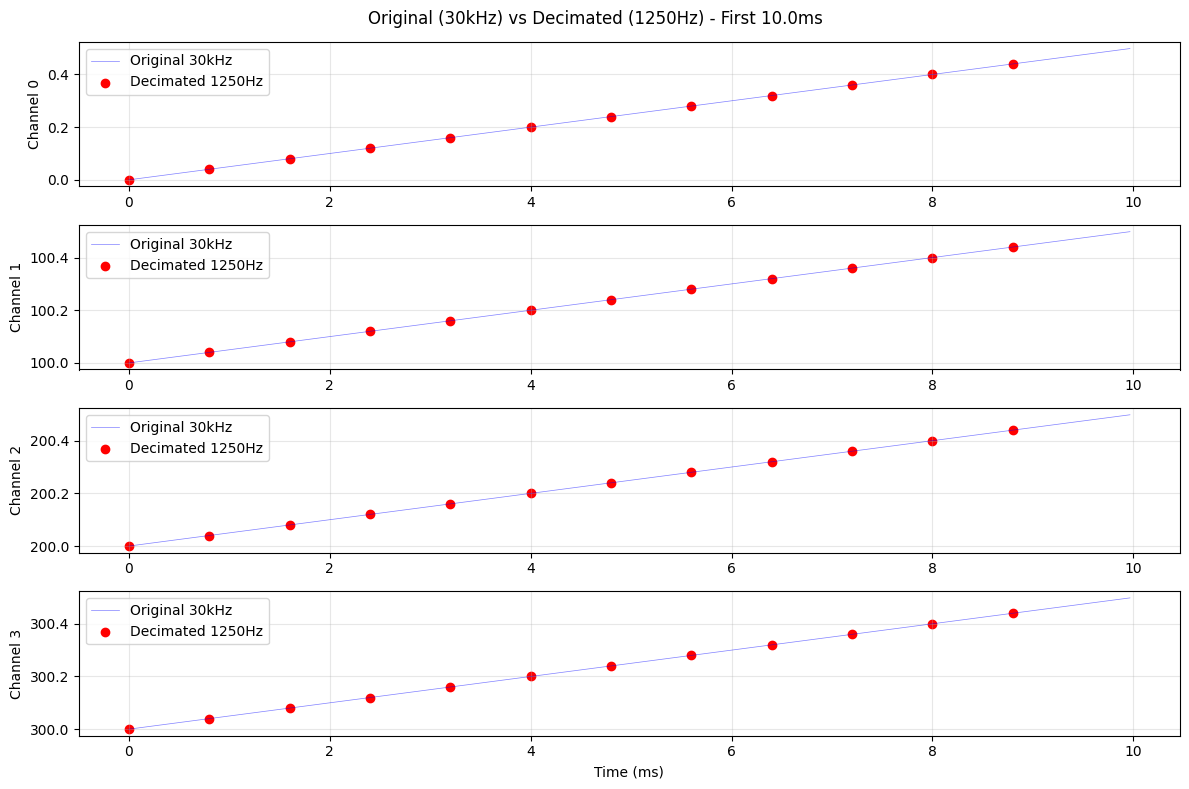

In [28]:
# Plot original vs decimated for visual verification
fig, axes = plt.subplots(num_channels, 1, figsize=(12, 8))

time_window = 0.01  # Plot first 10ms
samples_original = int(time_window * fs)
samples_decimated = int(time_window * dec_rec.get_sampling_frequency())

original_data = rec.get_traces(start_frame=0, end_frame=samples_original, segment_index=0)
decimated_data = dec_rec.get_traces(start_frame=0, end_frame=samples_decimated, segment_index=0)

time_original = np.arange(samples_original) / fs * 1000  # Convert to ms
time_decimated = np.arange(samples_decimated) / dec_rec.get_sampling_frequency() * 1000

for ch in range(num_channels):
    ax = axes[ch] if num_channels > 1 else axes
    
    # Plot original data
    ax.plot(time_original, original_data[:, ch], 'b-', alpha=0.5, linewidth=0.5, label='Original 30kHz')
    
    # Plot decimated data
    ax.scatter(time_decimated, decimated_data[:, ch], color='r', label='Decimated 1250Hz')
    
    ax.set_ylabel(f'Channel {ch}')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (ms)')
plt.suptitle(f'Original (30kHz) vs Decimated (1250Hz) - First {time_window*1000}ms')
plt.tight_layout()
plt.show()

In [32]:
# Save decimated recording using write_binary_recording
import os
os.makedirs('eeg_output', exist_ok=True)

write_binary_recording(
    dec_rec,
    file_paths='eeg_output/eeg.dat',
    dtype='float32',  # Keep as float32 to preserve values for verification
    n_jobs=4,  # Use 4 parallel workers
    chunk_duration='0.1s',  # Process in 100ms chunks
    progress_bar=True,
    verbose=True
)

print("\nBinary file saved!")

write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=125 - chunk_memory=1.95 KiB - total_memory=7.81 KiB - chunk_duration=0.10s (100.00 ms)


write_binary_recording (workers: 4 processes):   0%|          | 0/200 [00:00<?, ?it/s]


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

Saved data shape: (25000, 4)
Expected shape: (25000, 4)
Data matches: True


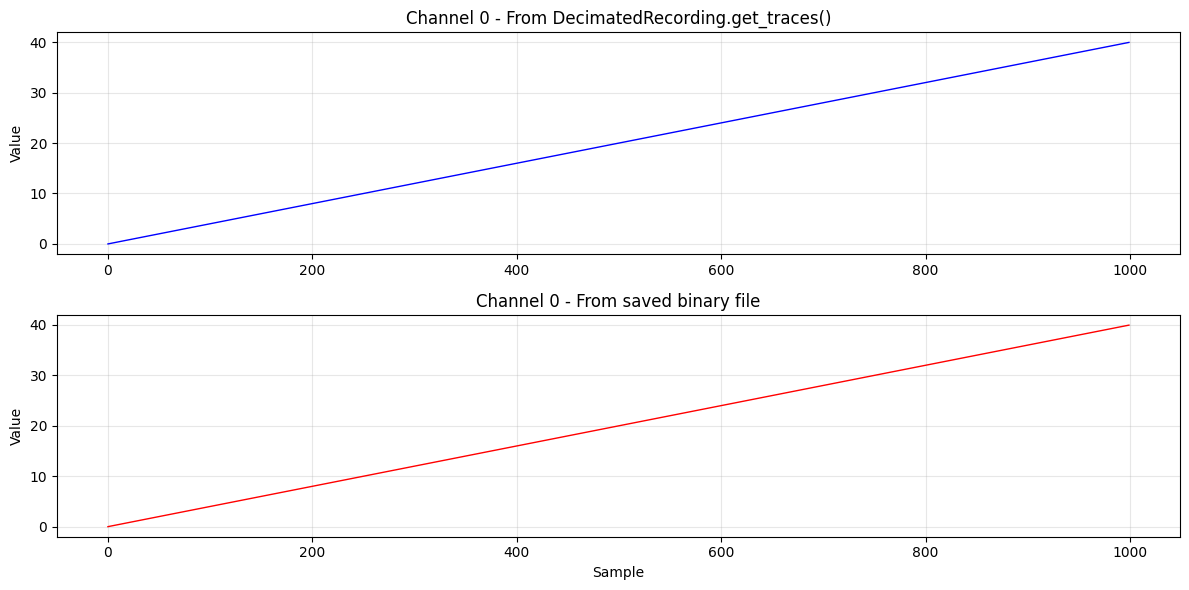

In [31]:
# Verify saved binary file by reading it back
saved_data = np.fromfile('eeg_output/eeg.dat', dtype='float32')
saved_data = saved_data.reshape(-1, num_channels)

print(f"Saved data shape: {saved_data.shape}")
print(f"Expected shape: ({dec_rec.get_num_samples(segment_index=0)}, {num_channels})")

# Compare with what we got from get_traces
all_decimated_traces = dec_rec.get_traces(start_frame=0, end_frame=dec_rec.get_num_samples(segment_index=0), segment_index=0)
print(f"Data matches: {np.allclose(saved_data, all_decimated_traces)}")

# Plot a comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot channel 0 from memory
axes[0].plot(all_decimated_traces[:1000, 0], 'b-', linewidth=1)
axes[0].set_title('Channel 0 - From DecimatedRecording.get_traces()')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Plot channel 0 from saved file
axes[1].plot(saved_data[:1000, 0], 'r-', linewidth=1)
axes[1].set_title('Channel 0 - From saved binary file')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def downsample_eeg_parallel(
    probe_dir: Path,
    rec: si.BaseRecording,
    target_fs: int,
    n_jobs: int = 8,
    chunk_duration: str = '1s',
    dtype: str = 'int16'
) -> None:
    """
    Downsample recording to EEG sampling rate using parallel on-the-fly decimation.
    
    This function uses DecimatedRecording for memory-efficient parallel processing.
    Saves only the binary .dat file without metadata.
    
    Parameters
    ----------
    probe_dir : Path
        Directory for the probe (e.g., output_path/ProbeA)
    rec : si.BaseRecording
        Concatenated recording to downsample (typically BinaryFolderRecording)
    target_fs : int
        Target sampling rate for EEG in Hz (e.g., 1250)
    n_jobs : int, default=8
        Number of parallel workers for write_binary_recording
    chunk_duration : str, default='1s'
        Duration of chunks for parallel processing (e.g., '1s', '0.5s')
    dtype : str, default='int16'
        Data type for saved binary file ('int16', 'float32', etc.)
        
    Notes
    -----
    - Only saves binary .dat file (no SpikeInterface metadata)
    - Uses on-the-fly decimation (memory efficient)
    - Parallelization only works in standalone scripts on Windows
    - For Jupyter notebooks on Windows, use n_jobs=1
    
    Examples
    --------
    >>> # In standalone script (parallelization works)
    >>> downsample_eeg_parallel(
    ...     probe_dir=Path('data/ProbeA'),
    ...     rec=concat_recording,
    ...     target_fs=1250,
    ...     n_jobs=8,
    ...     chunk_duration='1s',
    ...     dtype='int16'
    ... )
    
    >>> # In Jupyter notebook (use sequential)
    >>> downsample_eeg_parallel(
    ...     probe_dir=Path('data/ProbeA'),
    ...     rec=concat_recording,
    ...     target_fs=1250,
    ...     n_jobs=1,  # Sequential on Windows/Jupyter
    ...     chunk_duration='1s',
    ...     dtype='int16'
    ... )
    """
    logger.info(f"Downsampling to EEG ({target_fs} Hz) with parallel decimation...")
    
    # Calculate decimation factor
    original_fs = rec.get_sampling_frequency()
    decimation_factor = int(original_fs / target_fs)
    actual_fs = original_fs / decimation_factor
    
    logger.info(f"Original: {original_fs} Hz → Target: {target_fs} Hz")
    logger.info(f"Decimation factor: {decimation_factor} (actual: {actual_fs} Hz)")
    logger.info(f"Parallel workers: {n_jobs}, Chunk duration: {chunk_duration}")
    
    # Check if EEG already exists
    eeg_dir = probe_dir / 'eeg'
    eeg_file = eeg_dir / 'eeg.dat'
    
    if eeg_file.exists():
        logger.info(f"EEG file already exists at {eeg_file}")
        logger.info("Skipping EEG downsampling")
        return
    
    # Create decimated recording
    dec_rec = DecimatedRecording(rec, decimation_factor=decimation_factor)
    
    logger.info(f"Decimated recording: {dec_rec.get_num_channels()} channels, "
               f"{dec_rec.get_num_samples()} samples @ {actual_fs} Hz")
    
    # Create output directory
    eeg_dir.mkdir(parents=True, exist_ok=True)
    logger.info(f"Saving EEG to: {eeg_file}")
    
    # Save using write_binary_recording for parallel processing
    write_binary_recording(
        dec_rec,
        file_paths=str(eeg_file),
        dtype=dtype,
        n_jobs=n_jobs,
        chunk_duration=chunk_duration,
        progress_bar=True,
        verbose=False  # Reduce verbosity, using logger instead
    )
    
    # Calculate file size for verification
    import os
    file_size_mb = os.path.getsize(eeg_file) / (1024 * 1024)
    expected_size_mb = (dec_rec.get_num_samples() * 
                       dec_rec.get_num_channels() * 
                       dec_rec.get_dtype().itemsize) / (1024 * 1024)
    
    logger.success(f"EEG saved: {dec_rec.get_num_channels()} channels, "
                  f"{dec_rec.get_num_samples()} samples @ {actual_fs} Hz")
    l